# 01 - EDA y diseño del experimento: cartel de promoción en góndola

**Proyecto:** experimento A/B en una cadena mayorista (mismo tipo de negocio
que Maxiconsumo, donde trabajé) que prueba un cartel de promoción nuevo
(**variante B**) contra el cartel actual (**variante A**) para la categoría
"Bebidas y almacén", en 4 sucursales durante 10 semanas.

**Nota sobre los datos:** el dataset (`data/raw/`) es 100% sintético, generado
con [`src/generate_data.py`](../src/generate_data.py). Cada fila es un
visitante que pasó por la góndola promocionada un día determinado, con la
variante que vio ese día, si compró la categoría y cuánto gastó si compró.

**Sobre el diseño del experimento (importante):** el cartel se cambia una vez
por día en cada sucursal -- no se le puede mostrar la variante A a un cliente y
la B a otro cliente el mismo día en la misma góndola. Por eso **la unidad de
randomización es el día**, no el cliente individual. Para que el día de la
semana (que afecta cuánta gente entra al local) no termine desbalanceando la
comparación, la asignación se hizo con **bloqueo por día de la semana**: para
cada sucursal y cada día de la semana, exactamente 5 de las 10 semanas
mostraron la variante A y las otras 5 la variante B. Esto se valida en la
sección 2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = "../data/raw"

df = pd.read_csv(f"{DATA_DIR}/experimento_cartel.csv", parse_dates=["fecha"])
print("Shape:", df.shape)
df.head()

Shape: (25473, 9)


,visitante_id,fecha,dia_semana,semana,sucursal,variante,categoria,compro,monto_ars
0,VIS0000001,2026-03-02,Lunes,1,Centro,B,Bebidas y almacén,False,NaN
1,VIS0000002,2026-03-02,Lunes,1,Centro,B,Bebidas y almacén,False,NaN
2,VIS0000003,2026-03-02,Lunes,1,Centro,B,Bebidas y almacén,False,NaN
3,VIS0000004,2026-03-02,Lunes,1,Centro,B,Bebidas y almacén,False,NaN
4,VIS0000005,2026-03-02,Lunes,1,Centro,B,Bebidas y almacén,False,NaN


## 1. Calidad de datos

In [2]:
print("Nulos por columna:\n", df.isnull().sum())
print("\nRango de fechas:", df["fecha"].min().date(), "a", df["fecha"].max().date())
print("Sucursales:", df["sucursal"].unique())
print("Variantes:", df["variante"].unique())
print("Total de visitantes:", len(df))
print("Total de días de experimento:", df["fecha"].nunique())

Nulos por columna:
 visitante_id        0
fecha               0
dia_semana          0
semana              0
sucursal            0
variante            0
categoria           0
compro              0
monto_ars       20370
dtype: int64

Rango de fechas: 2026-03-02 a 2026-05-09
Sucursales: ['Centro' 'Norte' 'Oeste' 'Sur']
Variantes: ['B' 'A']
Total de visitantes: 25473
Total de días de experimento: 60


## 2. Chequeo de balance de la randomización

Antes de mirar cualquier resultado, hay que confirmar que el diseño se
ejecutó como se planeó: ¿cada combinación sucursal x día de la semana realmente
tiene 5 días con A y 5 con B? Si esto no estuviera balanceado, cualquier
diferencia que veamos después podría deberse al día de la semana y no al
cartel.

In [3]:
dias_unicos = df.drop_duplicates(["fecha", "sucursal"])[["fecha", "sucursal", "dia_semana", "variante"]]

balance = pd.crosstab([dias_unicos["sucursal"], dias_unicos["dia_semana"]], dias_unicos["variante"])
balance

variante             A  B
sucursal dia_semana      
Centro   Jueves      5  5
         Lunes       5  5
         Martes      5  5
         Miércoles   5  5
         Sábado      5  5
         Viernes     5  5
Norte    Jueves      5  5
         Lunes       5  5
         Martes      5  5
         Miércoles   5  5
         Sábado      5  5
         Viernes     5  5
Oeste    Jueves      5  5
         Lunes       5  5
         Martes      5  5
         Miércoles   5  5
         Sábado      5  5
         Viernes     5  5
Sur      Jueves      5  5
         Lunes       5  5
         Martes      5  5
         Miércoles   5  5
         Sábado      5  5
         Viernes     5  5

In [4]:
print("Visitantes totales por variante:")
print(df["variante"].value_counts())
print("\nVisitantes por sucursal y variante:")
print(pd.crosstab(df["sucursal"], df["variante"]))

Visitantes totales por variante:
variante
B    12762
A    12711
Name: count, dtype: int64

Visitantes por sucursal y variante:
variante     A     B
sucursal            
Centro    4194  4274
Norte     2814  2833
Oeste     3248  3295
Sur       2455  2360


**A completar:** ¿el balance de días por variante es exactamente 5 y 5 en
todas las combinaciones? ¿la cantidad total de visitantes es parecida entre A
y B? Un balance perfecto en los días (por diseño) no garantiza una cantidad
idéntica de visitantes, porque el tráfico varía día a día -- pero sí garantiza
que, en promedio, ambas variantes estuvieron expuestas a la misma mezcla de
días de la semana.

## 3. Por qué importaba bloquear por día de la semana

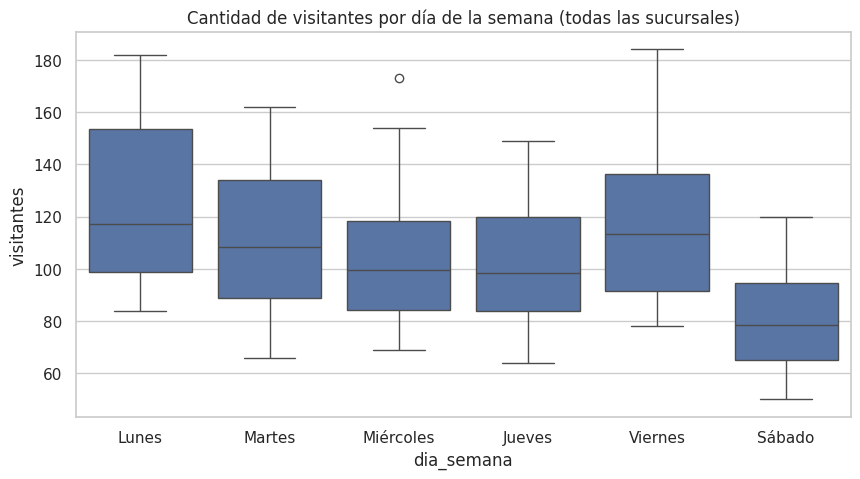

In [5]:
visitas_por_dia = df.groupby(["fecha", "sucursal"]).size().reset_index(name="visitantes")
visitas_por_dia = visitas_por_dia.merge(dias_unicos, on=["fecha", "sucursal"])

orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado"]
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=visitas_por_dia, x="dia_semana", y="visitantes", order=orden_dias, ax=ax)
ax.set_title("Cantidad de visitantes por día de la semana (todas las sucursales)")
plt.show()

**A completar:** ¿hay diferencias claras de tráfico entre días de la
semana (por ejemplo, lunes/viernes más alto, sábado más bajo)? Si esas
diferencias existieran y por mala suerte la asignación al azar hubiera puesto,
por ejemplo, más sábados en la variante A que en la B, cualquier diferencia de
conversión observada podría deberse simplemente a que un día tiene menos
tráfico -- no al cartel. El bloqueo por día de semana (sección 2) es lo que
descarta esta posible fuente de confusión.

## 4. Conversión y ticket promedio: primera mirada

In [6]:
conversion_por_variante = df.groupby("variante")["compro"].mean()
ticket_por_variante = df[df["compro"]].groupby("variante")["monto_ars"].mean()

print("Conversión (fracción de visitantes que compraron la categoría):")
print(conversion_por_variante.round(3))
print("\nTicket promedio (ARS, solo compradores):")
print(ticket_por_variante.round(0))

Conversión (fracción de visitantes que compraron la categoría):
variante
A    0.180
B    0.221
Name: compro, dtype: float64

Ticket promedio (ARS, solo compradores):
variante
A    44515.0
B    48093.0
Name: monto_ars, dtype: float64


**Importante:** estos números agregados a nivel de todos los visitantes
juntos son solo una primera mirada exploratoria -- **no** son todavía el
análisis estadístico del experimento. Como la unidad de randomización fue el
día (no el visitante individual), el test de hipótesis formal del notebook 03
va a comparar días entre sí, no visitantes sueltos entre sí. Acá solo estamos
mirando la forma general de los datos.

## 5. Variabilidad día a día por variante

In [7]:
metricas_diarias = df.groupby(["fecha", "sucursal", "variante", "dia_semana", "semana"]).agg(
    visitantes=("visitante_id", "count"),
    compras=("compro", "sum"),
).reset_index()
metricas_diarias["conversion_dia"] = metricas_diarias["compras"] / metricas_diarias["visitantes"]

ticket_diario = df[df["compro"]].groupby(["fecha", "sucursal"])["monto_ars"].mean().reset_index()
ticket_diario.columns = ["fecha", "sucursal", "ticket_promedio_dia"]

metricas_diarias = metricas_diarias.merge(ticket_diario, on=["fecha", "sucursal"], how="left")

print(metricas_diarias.shape)
metricas_diarias.head()

(240, 9)


,fecha,sucursal,variante,dia_semana,semana,visitantes,compras,conversion_dia,ticket_promedio_dia
0,2026-03-02,Centro,B,Lunes,1,157,28,0.178344,43764.923571
1,2026-03-02,Norte,A,Lunes,1,110,23,0.209091,46633.181304
2,2026-03-02,Oeste,B,Lunes,1,129,11,0.085271,37268.610000
3,2026-03-02,Sur,A,Lunes,1,94,12,0.127660,50657.785000
4,2026-03-03,Centro,A,Martes,1,145,25,0.172414,40908.787200


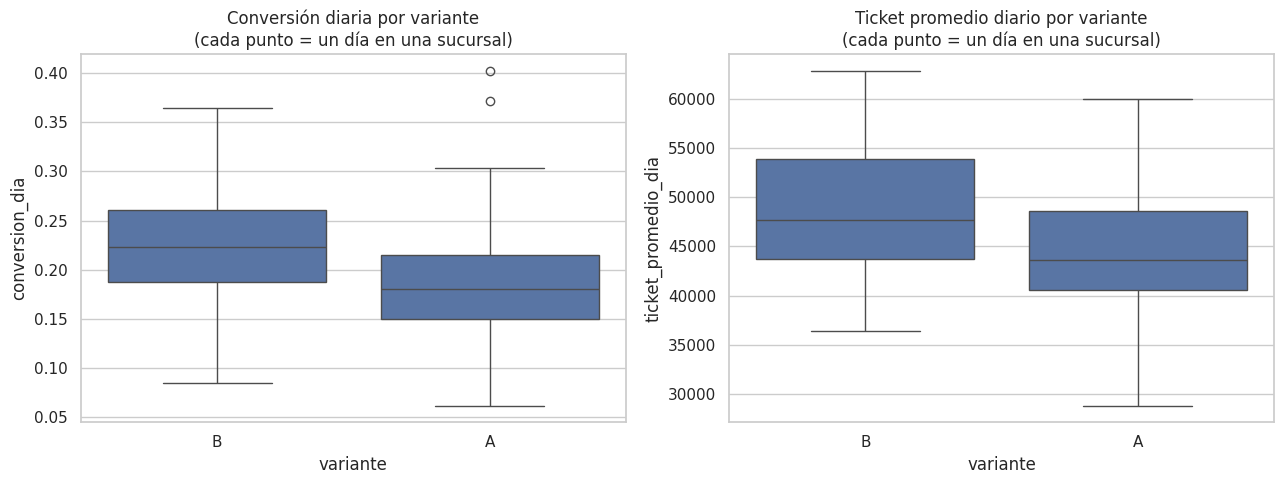

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=metricas_diarias, x="variante", y="conversion_dia", ax=axes[0])
axes[0].set_title("Conversión diaria por variante\n(cada punto = un día en una sucursal)")

sns.boxplot(data=metricas_diarias, x="variante", y="ticket_promedio_dia", ax=axes[1])
axes[1].set_title("Ticket promedio diario por variante\n(cada punto = un día en una sucursal)")

plt.tight_layout()
plt.show()

**A completar:** ¿se nota una diferencia visual entre A y B en conversión
diaria? ¿y en ticket promedio diario? ¿hay superposición entre las cajas (lo
cual sugiere que la diferencia, si existe, no es enorme comparada con la
variabilidad día a día)? Esta variabilidad entre días es exactamente lo que el
test de hipótesis del notebook 03 va a cuantificar formalmente.

## 6. Guardar métricas diarias para el notebook 02 y 03

In [9]:
import os
os.makedirs("../data/processed", exist_ok=True)
metricas_diarias.to_csv("../data/processed/metricas_diarias.csv", index=False)
print("Guardado data/processed/metricas_diarias.csv con", len(metricas_diarias), "filas (una por día x sucursal)")

Guardado data/processed/metricas_diarias.csv con 240 filas (una por día x sucursal)


## Conclusiones

**A completar**, pero como guía de qué mirar:

- El chequeo de balance confirma que el bloqueo por día de semana funcionó
  como se diseñó (5 y 5 en cada combinación sucursal x día).
- El tráfico varía notablemente según el día de la semana -- justamente el
  motivo por el que bloquear la randomización era importante.
- La variante B muestra, a primera vista, conversión y ticket promedio más
  altos, pero con variabilidad día a día considerable -- falta cuantificar si
  esa diferencia es estadísticamente significativa.

**Próximos notebooks:** el notebook 02 calcula qué tamaño de muestra hubiera
hecho falta para detectar un efecto de esta magnitud con confianza razonable
(la pregunta que hay que hacerse *antes* de correr un experimento); el
notebook 03 corre el test de hipótesis formal sobre las métricas diarias y
llega a una recomendación de negocio.